# Practical Statistics for Data Scientists (Python)
# Chapter 3. Statistial Experiments and Significance Testing
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

**Reproduksi dan pembahasan:** Nanda Pratama ITM · NIM 101032330212 · TK 47 01.

Kode diadaptasi dari repositori resmi Peter Bruce, Andrew Bruce, dan Peter Gedeck (GPL-3.0); bukan klaim kode orisinal mahasiswa. Penjelasan Indonesia dan eksperimen tambahan disusun dengan bantuan AI. Sumber serta koreksi tercatat pada README dan docs/PERUBAHAN.md.

## Petunjuk penggunaan dan sumber

Baca teori berikut, kemudian jalankan sel kode berurutan dari atas ke bawah. Bagian **Reproduksi kode buku** mempertahankan semua sel Python nonkosong sumber resmi dengan koreksi yang dicatat. Bagian **Eksperimen tambahan** adalah pengembangan edukatif. Notebook gabungan ini telah dijalankan berurutan pada kernel baru, termasuk eksperimen tambahan.

Referensi utama: Bruce, Bruce, & Gedeck (2020), *Practical Statistics for Data Scientists*, edisi ke-2. [Kode resmi](https://github.com/gedeck/practical-statistics-for-data-scientists), commit `8a6d3bb6468e979c861d4b37215e1413702dfdfa`. Lihat [catatan perubahan](../docs/PERUBAHAN.md).

# Ringkasan dan pendalaman teori Bab 3

Eksperimen membandingkan efek yang diamati dengan variasi yang mungkin terjadi secara kebetulan. Bab ini menghubungkan desain eksperimen, hipotesis, resampling, pengujian parametrik, dan ukuran sampel. Signifikansi perlu dibaca bersama ukuran efek serta konteks penggunaan.


## A/B testing dan hipotesis
A/B testing membagi unit secara acak ke kontrol A dan perlakuan B. Kontrol membantu memisahkan efek perlakuan dari perubahan umum seperti musim. Tentukan metrik, unit randomisasi, ukuran sampel, durasi, dan arah hipotesis sebelum melihat hasil. Pengunjung berulang atau unit yang berinteraksi dapat melanggar independensi. Menambah banyak versi meningkatkan masalah multiple testing.

H0 biasanya menyatakan tidak ada perbedaan; H1 menyatakan perbedaan yang ingin dideteksi. Uji dua sisi mendeteksi kedua arah, sedangkan satu sisi hanya arah yang telah ditentukan. Gagal menolak H0 tidak membuktikan kesetaraan. Uji ekuivalensi memerlukan batas efek yang dianggap tidak bermakna dan desain tersendiri.


## Permutation test
Jika label perlakuan dapat dipertukarkan di bawah H0, gabungkan hasil lalu acak label dengan ukuran kelompok tetap. Hitung statistik, misalnya rata-rata B dikurangi A, pada setiap permutasi. Posisi selisih aktual terhadap distribusi nol menunjukkan keekstreman hasil. Asumsi exchangeability penting; data berpasangan perlu pengacakan sesuai pasangan.

Permutasi exhaustive mencakup seluruh susunan label; Monte Carlo hanya sebagian. Bootstrap mengambil ulang dengan pengembalian dan berbeda dari permutasi. Estimasi p Monte Carlo dapat memakai $(b+1)/(B+1)$ agar tidak melaporkan p=0 akibat simulasi terbatas. Contoh sumber memakai proporsi sederhana sehingga hasilnya dipahami sebagai estimasi simulasi.


## p-value, alpha, dan error
p-value adalah peluang statistik minimal se-ekstrem yang diamati jika H0 dan asumsi model berlaku. Ini bukan peluang H0 benar, bukan ukuran efek, dan bukan peluang hasil akan bereplikasi. Alpha adalah ambang keputusan yang ditetapkan sebelumnya. Error tipe I berarti menolak H0 yang benar; tipe II berarti gagal menolak H0 ketika alternatif tertentu benar. Power adalah 1-beta.

Sampel besar dapat membuat efek sangat kecil signifikan. Laporkan selisih absolut, relatif, ketidakpastian, dan manfaat/biaya tindakan. Pada contoh konversi, selisih proporsi yang dikali 100 dibaca sebagai poin persentase. Melihat p-value berulang lalu berhenti ketika signifikan mengubah tingkat kesalahan; gunakan desain sequential yang sesuai jika pemantauan diperlukan.


## t-test dan derajat bebas
Welch t-test memakai $t=(\bar{x}_A-\bar{x}_B)/\sqrt{s_A^2/n_A+s_B^2/n_B}$ dan tidak mengharuskan varians populasi sama. Derajat bebas Welch bergantung pada ukuran dan varians kelompok. Uji berpasangan diterapkan pada selisih pasangan dan berbeda dari uji independen. Di notebook, hipotesis waktu B lebih lama ditulis sebagai A lebih kecil melalui `alternative='less'`.

Derajat bebas adalah banyaknya informasi bebas setelah parameter atau batasan diestimasi. Pada varians sampel, residual terhadap mean berjumlah nol sehingga hanya n-1 residual bebas. Ketepatan inferensi sampel kecil dipengaruhi bentuk distribusi dan pencilan. Pilihan uji tidak memperbaiki desain atau sampling yang bias.


## Multiple testing
Untuk m uji independen pada alpha yang sama, peluang setidaknya satu false positive adalah $1-(1-\alpha)^m$. Bonferroni memakai alpha/m untuk mengontrol family-wise error dan tetap valid sebagai batas konservatif tanpa independensi. Benjamini-Hochberg mengendalikan false discovery rate pada kondisi yang sesuai. Pemilihan fitur dan pencarian hyperparameter berulang juga menimbulkan optimisme; evaluasi akhir perlu data terpisah.


## ANOVA
ANOVA menguji kesamaan mean beberapa kelompok. $F=MS_{antara}/MS_{dalam}$ membandingkan variasi mean kelompok terhadap variasi residual. Dengan g kelompok dan N pengamatan, derajat bebasnya g-1 dan N-g. p-value berasal dari ekor kanan F. **F dan p-value tidak dibagi dua**; kesalahan pada contoh sumber telah diperbaiki. Signifikan berarti setidaknya satu mean berbeda, bukan semua pasangan berbeda. Post-hoc memerlukan koreksi yang tepat.

ANOVA klasik mengasumsikan error independen, varians sebanding, serta normalitas residual untuk inferensi eksak. ANOVA dua arah melibatkan dua faktor dan dapat mencakup interaksi: efek suatu faktor bergantung pada level faktor lain. Jenis sum of squares perlu diperhatikan untuk desain tidak seimbang. Tambahan notebook memperagakan interaksi dua faktor pada data simulasi yang diberi label jelas.


## Chi-square, Fisher, dan pola digit
Untuk independensi pada tabel, expected count $E_{ij}=R_iC_j/N$. Statistik $\chi^2=\sum_{ij}(O_{ij}-E_{ij})^2/E_{ij}$ memiliki df (r-1)(c-1) pada pendekatan asimtotik. Expected count kecil dapat membuat pendekatan kurang akurat; gunakan metode eksak/simulasi yang sesuai. Pearson residual membantu menemukan sel penyumbang penyimpangan.

Fisher exact mengondisikan pada margin tabel dan cocok untuk contoh 2x2 kecil. Notebook menambahkan contoh 2x2 Python yang dieksekusi. Asosiasi kategori bukan bukti kausalitas. Pola digit yang tidak seragam pada contoh Imanishi dapat memicu pemeriksaan kualitas, tetapi tidak cukup untuk menyimpulkan kecurangan tanpa mekanisme pengukuran dan bukti lain.


## Multi-arm bandit
Bandit menyeimbangkan exploration (mencoba untuk belajar) dan exploitation (memakai pilihan terbaik saat ini). Epsilon-greedy memilih acak dengan peluang epsilon. Thompson sampling mengambil sampel dari posterior; upper confidence bound memberi bonus ketidakpastian. Tujuannya meningkatkan reward selama eksperimen. Data adaptif tidak boleh dianalisis seolah alokasinya A/B tetap. Tambahan simulasi memperlihatkan jumlah pemilihan dan reward setiap arm; itu bukan estimasi hasil eksperimen riil.


## Power dan ukuran sampel
Ukuran sampel bergantung pada alpha, power, variasi, rasio alokasi, dan efek minimum bermakna. Efek kecil membutuhkan sampel lebih besar. Cohen's h untuk proporsi adalah $2\arcsin\sqrt{p_1}-2\arcsin\sqrt{p_2}$. Sumber menggunakan transformasi itu dalam perhitungan power; tambahan memakai pendekatan normal dua proporsi dan membulatkan kebutuhan per kelompok ke atas. Angka yang keluar adalah kebutuhan desain berdasarkan asumsi, bukan bukti efek akan terjadi.


## Interpretasi dan kesimpulan
Bandingkan selisih waktu aktual dengan histogram permutasi dan Welch t-test. Cocokkan ANOVA SciPy dengan tabel statsmodels. Amati penurunan kebutuhan sampel ketika efek minimum diperbesar. Dalam ML/DL, membandingkan model memerlukan rancangan evaluasi konsisten, ukuran efek, dan pertimbangan banyaknya percobaan.


# Reproduksi kode buku
Sel berikut diadaptasi dari penulis asli. Komentar Inggris dipertahankan untuk memudahkan pencocokan sumber. Teori serta interpretasi Indonesia tersedia di atas dan pada bagian akhir.

## Persiapan kernel: jalankan sebelum kode bab

`ModuleNotFoundError` berarti modul belum tersedia di kernel yang dipilih. Sel berikut memeriksa dependensi dan memasang paket yang diperlukan **ke Python yang sedang dipakai notebook**, bukan ke Python lain. Pemasangan pertama memerlukan internet dan dapat memakan beberapa menit. Gunakan Python 3.12 (versi pengujian). Setelah itu, jalankan kode bab dari atas ke bawah. Jika masih gagal, perhatikan nama modul dan pesan pemasangan yang muncul; jangan melewati sel persiapan.

In [1]:
# Jalankan sel ini lebih dahulu: paket dipasang ke Python/kernel yang aktif.
import sys
import importlib.util
import importlib
import subprocess
from pathlib import Path

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'requirements-lock.txt').is_file() and (p / 'data').is_dir()), None)
if REPO is None:
    raise FileNotFoundError('Buka folder Practical-Statistics-for-Data-Scientists di VS Code, lalu buka notebook dari folder notebooks.')

paket = {
    'numpy': 'numpy', 'pandas': 'pandas', 'scipy': 'scipy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels', 'wquantiles': 'wquantiles', 'pygam': 'pygam',
    'dmba': 'dmba', 'pydotplus': 'pydotplus', 'imblearn': 'imbalanced-learn',
    'xgboost': 'xgboost', 'prince': 'prince', 'adjustText': 'adjustText',
    'IPython': 'ipython', 'graphviz': 'graphviz'
}
kurang = [nama for modul, nama in paket.items() if importlib.util.find_spec(modul) is None]
print('Python/kernel aktif:', sys.executable)
print('Versi Python:', sys.version.split()[0])
if kurang:
    print('Paket belum tersedia:', ', '.join(kurang))
    print('Memasang dependensi ke kernel ini. Internet diperlukan pada pemasangan pertama.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REPO / 'requirements-lock.txt')])
    importlib.invalidate_caches()
    print('Pemasangan selesai. Jika library sudah diimpor sebelum pemasangan, pilih Restart Kernel lalu Run All.')
else:
    print('Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.')

Python/kernel aktif: D:\Kuliah\DL\.venv-statistics\Scripts\python.exe
Versi Python: 3.12.14
Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.


In [2]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [4]:
DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'state.csv').exists()), None)
assert DATA is not None, 'Jalankan notebook dari folder repositori atau notebooks.'
print('Data:', DATA)

Data: D:\Kuliah\DL\UPLOAD_GITHUB\Practical-Statistics-for-Data-Scientists\data


Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [5]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

# Resampling

In [6]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

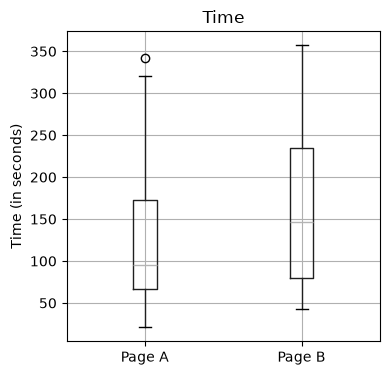

In [7]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [8]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


The following code is different to the R version. idx_A and idx_B are reversed.

In [9]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()
    
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

35.09523809523809


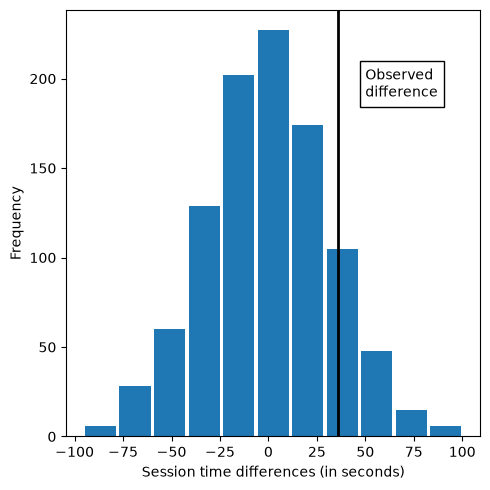

In [10]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
# convert perm_diffs to numpy array to avoid problems with some Python installations
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


# Statistical Significance and P-Values

Observed difference: 0.0368%


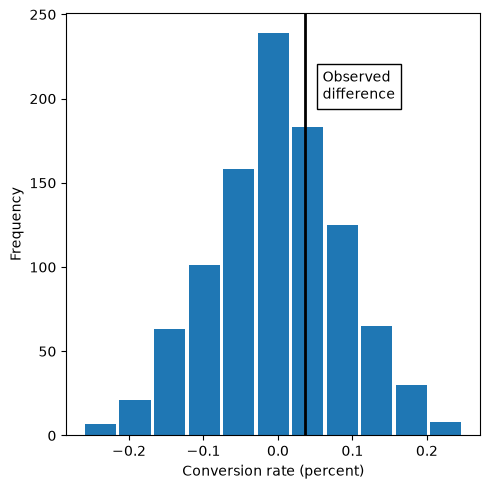

In [12]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588) 
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## P-Value
If `np.mean` is applied to a list of booleans, it gives the percentage of how often True was found in the list (#True / #Total).

In [13]:
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


In [14]:
# Uji dua proporsi satu sisi: A > B; arah ditentukan sebelum melihat hasil.
z_stat, p_value = sm.stats.proportions_ztest([200, 182], [23739, 22588], alternative='larger')
print(f'z = {z_stat:.4f}; p-value satu sisi = {p_value:.4f}')

z = 0.4373; p-value satu sisi = 0.3309


# t-Tests

In [15]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time, 
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False, alternative='less')
print(f'p-value for single sided test: {res.pvalue:.4f}')

p-value for single sided test: 0.1408


In [16]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time, 
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


# ANOVA

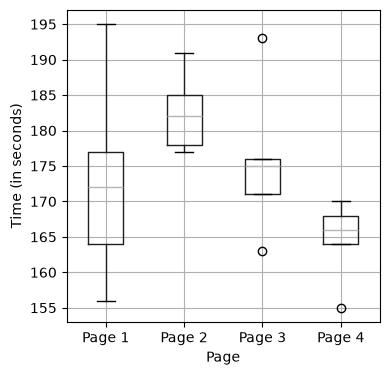

In [17]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

In [18]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


In [19]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]
    
print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
19.63999999999999


Pr(Prob) 0.08666666666666667


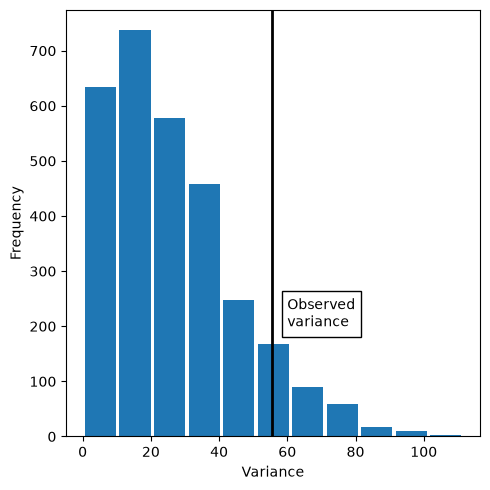

In [20]:
random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## F-Statistic
We can compute an ANOVA table using statsmodel.

In [21]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
                
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [22]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time, 
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic:.4f}')
print(f'p-value: {res.pvalue:.4f}')

F-Statistic: 2.7398
p-value: 0.0776


### Two-way anova only available with statsmodels
```
formula = 'len ~ C(supp) + C(dose) + C(supp):C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
```

# Chi-Square Test
## Chi-Square Test: A Resampling Approach

In [23]:
# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [24]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [25]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(np.asarray(perm_chi2) >= chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4910


In [26]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


The above algorithm uses sampling into the three sets without replacement. Alternatively, it is also possible to sample with replacement.

In [27]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.choices(box, k=1000)),
                     sum(random.choices(box, k=1000)),
                     sum(random.choices(box, k=1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(np.asarray(perm_chi2) >= chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.6350


## Figure chi-sq distribution

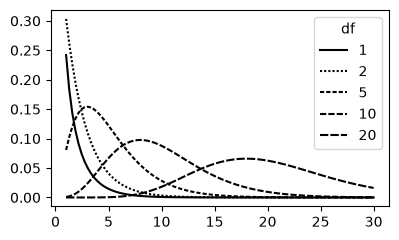

In [28]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

## Fisher exact test
Catatan pada sumber berkaitan dengan versi SciPy lama dan keterbatasan tabel umum. Bagian tambahan menyediakan uji Fisher 2x2 yang dieksekusi tanpa kompiler Fortran.

In [29]:
# stats.fisher_exact(clicks.values)

### Scientific Fraud

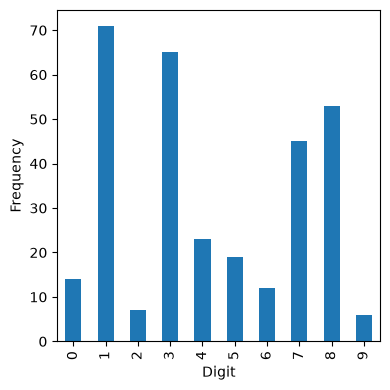

In [30]:
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Power and Sample Size
statsmodels has a number of methods for power calculation

see e.g.: https://machinelearningmastery.com/statistical-power-and-power-analysis-in-python/

In [31]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.391


In [32]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408


# Eksperimen tambahan dan validasi
Sel berikut disusun sebagai pendalaman. Output muncul setelah sel kode dijalankan.

## Eksperimen tambahan: validasi ANOVA, Fisher, koreksi multipel, dan power
ANOVA diverifikasi antara SciPy dan statsmodels. Data untuk ANOVA dua arah di bawah adalah simulasi edukatif, bukan pengamatan dari buku.

In [33]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower
DATA = next(p/'data' for p in [Path.cwd(), *Path.cwd().parents] if (p/'data'/'state.csv').exists())
a = pd.read_csv(DATA/'four_sessions.csv')
f_result = stats.f_oneway(*(g.Time.to_numpy() for _,g in a.groupby('Page')))
table = sm.stats.anova_lm(smf.ols('Time ~ C(Page)',data=a).fit())
assert np.isclose(f_result.statistic,table.loc['C(Page)','F'])
assert np.isclose(f_result.pvalue,table.loc['C(Page)','PR(>F)'])
print('ANOVA terverifikasi: F =',f_result.statistic, '; p =',f_result.pvalue)
print('Fisher 2x2 (contoh kecil):',stats.fisher_exact([[8,2],[1,5]],alternative='two-sided'))
p = [.001,.01,.03,.2]
display(pd.DataFrame({'p_raw':p,'p_Bonferroni':multipletests(p,method='bonferroni')[1],'p_BH':multipletests(p,method='fdr_bh')[1]}))
h = sm.stats.proportion_effectsize(.0121,.011)
n = NormalIndPower().solve_power(effect_size=h,alpha=.05,power=.8,ratio=1,alternative='larger')
print('Kebutuhan sampel pendekatan normal: per kelompok =',int(np.ceil(n)), '; total =',2*int(np.ceil(n)))
rng = np.random.default_rng(42)
d = pd.DataFrame([(a,b) for a in ['kontrol','perlakuan'] for b in ['mobile','desktop'] for _ in range(30)],columns=['versi','perangkat'])
d['y'] = 10 + 2*(d.versi=='perlakuan') + 1*(d.perangkat=='mobile') + 3*((d.versi=='perlakuan') & (d.perangkat=='mobile')) + rng.normal(0,2,len(d))
display(sm.stats.anova_lm(smf.ols('y ~ C(versi)*C(perangkat)',data=d).fit(),typ=2))

ANOVA terverifikasi: F = 2.739825341901467 ; p = 0.07758621525801461
Fisher 2x2 (contoh kecil): SignificanceResult(statistic=np.float64(20.0), pvalue=np.float64(0.034965034965034975))


,p_raw,p_Bonferroni,p_BH
0,0.001,0.004,0.004
1,0.010,0.040,0.020
2,0.030,0.120,0.040
3,0.200,0.800,0.200


Kebutuhan sampel pendekatan normal: per kelompok = 116602 ; total = 233204


,sum_sq,df,F,PR(>F)
C(versi),269.505332,1.0,110.320682,1.533124e-18
C(perangkat),198.462340,1.0,81.239583,4.843815e-15
C(versi):C(perangkat),93.555218,1.0,38.296368,9.435967e-09
Residual,283.379490,116.0,NaN,NaN


## Simulasi tambahan: epsilon-greedy bandit
Tiga arm memiliki peluang sukses tetap yang diketahui hanya oleh simulator. Algoritma belajar dari reward yang diamati. Frekuensi pemilihan tidak seragam karena alokasi adaptif.

In [34]:
rng = np.random.default_rng(42)
true_p = np.array([.04,.06,.09]); counts=np.zeros(3,dtype=int); rewards=np.zeros(3)
for t in range(5000):
    if t<3: arm=t
    elif rng.random()<.1: arm=int(rng.integers(3))
    else: arm=int(np.argmax(rewards/counts))
    counts[arm]+=1; rewards[arm]+=int(rng.random()<true_p[arm])
display(pd.DataFrame({'p_simulator':true_p,'dipilih':counts,'sukses':rewards.astype(int),'reward_rate':rewards/counts}))
assert counts.sum()==5000

,p_simulator,dipilih,sukses,reward_rate
0,0.04,212,11,0.051887
1,0.06,218,17,0.077982
2,0.09,4570,392,0.085777


**Kesimpulan:** koreksi multipel mengubah keputusan yang mungkin dibuat dari p mentah. Power bergantung pada efek target dan asumsi. Bandit mengalokasikan lebih banyak kesempatan pada arm yang tampak menguntungkan; hasilnya bukan A/B dengan alokasi tetap.

## Ringkasan hasil yang diperoleh

Jalankan semua sel sebelumnya, kemudian sel berikut untuk menampilkan ringkasan dari hasil perhitungan saat ini.

In [35]:
# Menggunakan hasil ANOVA dari eksperimen yang baru dijalankan.
print(f'ANOVA: F={f_result.statistic:.4f}; p={f_result.pvalue:.4f}')
print('Keputusan pada alpha 0.05:',
      'Tolak H0' if f_result.pvalue < 0.05 else 'Tidak menolak H0')
print('Keputusan ini bukan bukti sebab-akibat atau ekuivalensi.')

ANOVA: F=2.7398; p=0.0776
Keputusan pada alpha 0.05: Tidak menolak H0
Keputusan ini bukan bukti sebab-akibat atau ekuivalensi.
